**Note**

These monster GPU cards are likely fairly undersaturated by this test condition, because the amount of compute is fairly low,

we're at best measuring when we hit the memory bandwidth limit (i.e., when the speed plateus with increasing batch sizes) and all sort of kernel overheads.

So think of it as "how well is our workload utilizing this particular GPU?"

Also the machines are rented on vast.ai, and each of them have different CPUs, memory, cooling, power supply, etc, so view this as a rough guide when you're thinking about purchasing a GPU.

Generally speaking, the consumer cards like RTX5090 is really cost effective for typical ptychography work, 

while data center cards like H100 or B200 will shine when huge amount of VRAM is needed, like multi-tilt ptychotomo or huge FOV reconstructions.

In [1]:
import os

work_dir = "H:/workspace/ptycho_benchmark"

os.chdir(work_dir)
print("Current working dir: ", os.getcwd())

Current working dir:  H:\workspace\ptycho_benchmark


In [2]:
import pandas as pd
import numpy as np
from benchlib.extract_metrics import parse_log, export_to_ndjson, PACKAGE_CONFIGS
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import matplotlib.gridspec as gridspec

# Parse log files into Pandas DataFrame

In [3]:
# 1. Define all your runs in a list of dictionaries

devices = [
    'RTX3090',
    'RTX4090',
    'RTX5090',
    'RTXPRO6000',
    'A100',
    'H100',
    'B200'
           ]

packages = [
    'phaser', 
    'ptyrad_reduce'
    ]


runs = []

for device in devices:
    
    runs.append(
        {   
        "title": "phaser",
        "log_path": f"logs/20260312_cloud/log_cloud_20260312_phaser_{device}_tBL_WSe2.txt",
        "pkg_key": "phaser",
        "metadata": {
                    "date": "2026-03-12",
                    "package": "phaser",
                    "label": "phaser",
                    "version": "0.2",
                    "backend": "jax",
                    "device": f"{device}",
                    "algorithm": "AD",
                    "dataset": "tBL_WSe2",
                    "Npix": 128,
                    "Nscans": 16384,
                    }
        },
    )
    
    runs.append(
        {
        "title": "ptyrad_reduce",
        "log_path": f"logs/20260312_cloud/log_cloud_20260312_ptyrad_reduce_{device}_tBL_WSe2.txt",
        "pkg_key": "ptyrad",
        "metadata": {
                    "date": "2026-03-12",
                    "package": "ptyrad",
                    "label": "ptyrad_reduce",
                    "version": "v0.1.0.b13",
                    "backend": "pytorch",
                    "device": f"{device}",
                    "algorithm": "AD",
                    "dataset": "tBL_WSe2",
                    "Npix": 128,
                    "Nscans": 16384,
                    }
        },
    )


# 2. Extract everything into one master list
all_records = []
for run in runs:
    records = parse_log(
        log_path=run["log_path"], 
        config=PACKAGE_CONFIGS[run["pkg_key"]], 
        metadata=run["metadata"]
    )
    export_to_ndjson(records, f"logs/20260312_cloud/{run['metadata']['date']}_{run['title']}_{run['metadata']['device']}.ndjson", mode='w')
    
    all_records.extend(records)
export_to_ndjson(all_records, f"logs/20260312_cloud/full_device_performance.ndjson", mode='w')

# 3. Create the master DataFrame
df = pd.DataFrame(all_records)

# 4. Setup figure output directory
output_dir = 'figures/'
os.makedirs(output_dir, exist_ok=True)

date_str = datetime.datetime.now().strftime("%Y%m%d") # date string used for file names

In [4]:
df

,date,package,label,version,backend,device,algorithm,dataset,Npix,Nscans,status,round_idx,batch,pmode,slice,iter_times
0,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,512,6,6,"[8.977, 4.56, 4.567, 4.543, 4.557, 4.555, 4.54..."
1,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,256,6,6,"[8.337, 4.6, 4.591, 4.581, 4.598, 4.589, 4.593..."
2,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,128,6,6,"[8.435, 4.741, 4.724, 4.72, 4.731, 4.738, 4.75..."
3,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,64,6,6,"[8.87, 5.163, 5.18, 5.159, 5.158, 5.156, 5.15,..."
4,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,32,6,6,"[9.45, 5.721, 5.703, 5.72, 5.742, 5.701, 5.69,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,2026-03-12,ptyrad,ptyrad_reduce,v0.1.0.b13,pytorch,B200,AD,tBL_WSe2,128,16384,success,1,64,6,6,"[6.523, 0.781, 0.78, 0.78, 0.779, 0.777, 0.774..."
108,2026-03-12,ptyrad,ptyrad_reduce,v0.1.0.b13,pytorch,B200,AD,tBL_WSe2,128,16384,success,1,32,6,6,"[6.29, 1.001, 1.004, 1.002, 0.997, 1.002, 0.99..."
109,2026-03-12,ptyrad,ptyrad_reduce,v0.1.0.b13,pytorch,B200,AD,tBL_WSe2,128,16384,success,1,16,6,6,"[7.162, 1.682, 1.657, 1.656, 1.637, 1.663, 1.6..."
110,2026-03-12,ptyrad,ptyrad_reduce,v0.1.0.b13,pytorch,B200,AD,tBL_WSe2,128,16384,success,1,8,6,6,"[8.903, 3.051, 3.202, 2.993, 3.007, 2.977, 2.9..."


In [5]:
df[df['label']=='phaser']

,date,package,label,version,backend,device,algorithm,dataset,Npix,Nscans,status,round_idx,batch,pmode,slice,iter_times
0,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,512,6,6,"[8.977, 4.56, 4.567, 4.543, 4.557, 4.555, 4.54..."
1,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,256,6,6,"[8.337, 4.6, 4.591, 4.581, 4.598, 4.589, 4.593..."
2,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,128,6,6,"[8.435, 4.741, 4.724, 4.72, 4.731, 4.738, 4.75..."
3,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,64,6,6,"[8.87, 5.163, 5.18, 5.159, 5.158, 5.156, 5.15,..."
4,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,32,6,6,"[9.45, 5.721, 5.703, 5.72, 5.742, 5.701, 5.69,..."
5,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,16,6,6,"[10.019, 6.287, 6.299, 6.313, 6.308, 6.364, 6...."
6,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,8,6,6,"[10.278, 6.627, 6.588, 6.581, 6.586, 6.704, 6...."
7,2026-03-12,phaser,phaser,0.2,jax,RTX3090,AD,tBL_WSe2,128,16384,success,1,4,6,6,"[11.254, 7.917, 7.74, 7.887, 7.768, 7.768, 7.8..."
16,2026-03-12,phaser,phaser,0.2,jax,RTX4090,AD,tBL_WSe2,128,16384,success,1,512,6,6,"[8.797, 3.513, 3.601, 3.558, 3.598, 3.583, 3.5..."
17,2026-03-12,phaser,phaser,0.2,jax,RTX4090,AD,tBL_WSe2,128,16384,success,1,256,6,6,"[8.133, 3.513, 3.508, 3.498, 3.512, 3.502, 3.5..."


# Clean up DataFrame with clean iter time and compilation time (mean, std)

In [6]:
# Define the packages that actually have a JIT/compilation overhead
compiled_packages = ["phaser", "ptyrad_reduce"]

# Select the successful runs and OOM runs
df_success = df[df["status"] == "success"].copy()
df_oom = df[df["status"] == "OOM"].copy()

# Filter out the 1st iteration that contains significant warm up and compilation time
WARMUP = 1 

# ==========================================
# 1. CALCULATE METRICS ON SUCCESSFUL RUNS
# ==========================================
# Calculate Steady State (clean_iter_time)
df_success["clean_iter_time"] = df_success["iter_times"].apply(
    lambda x: np.mean(x[WARMUP:]) if isinstance(x, list) and len(x) > WARMUP else (x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
)

# Calculate Compilation Time (First Iteration - Steady State)
def calc_compile_time(row):
    if row["label"] in compiled_packages:
        x = row["iter_times"]
        if isinstance(x, list) and len(x) > 0:
            first_iter = x[0]
            steady_state = row["clean_iter_time"]
            
            # Ensure we have a valid steady state to subtract from
            if pd.notnull(steady_state):
                return first_iter - steady_state
    
    # Returns NaN if not in the list, or if the data is corrupted
    return np.nan

df_success["compile_time"] = df_success.apply(calc_compile_time, axis=1)

# ==========================================
# 2. PREP OOMs AND MERGE
# ==========================================
# Explicitly set both metrics to NaN for OOMs so they don't break the math
df_oom["clean_iter_time"] = np.nan
df_oom["compile_time"] = np.nan

# Merge them together BEFORE the groupby
df_success_and_oom = pd.concat([df_success, df_oom], ignore_index=True)

# ==========================================
# 3. AGGREGATE ACROSS ROUNDS
# ==========================================
# Group by the master dataframe, calculating mean and std for BOTH metrics
agg_df = df_success_and_oom.groupby(["label", "device", "batch", "pmode", "slice", "Nscans"]).agg({
    "clean_iter_time": ['mean', 'std'],
    "compile_time": ['mean', 'std']
}).reset_index()

# Flatten the annoying MultiIndex columns that Pandas creates when aggregating multiple columns
# This turns ('clean_iter_time', 'mean') into 'clean_iter_time_mean'
agg_df.columns = ['_'.join(col).strip('_') for col in agg_df.columns.values]

In [7]:
agg_df[agg_df['label']=='ptyrad_reduce']

,label,device,batch,pmode,slice,Nscans,clean_iter_time_mean,clean_iter_time_std,compile_time_mean,compile_time_std
56,ptyrad_reduce,A100,4,6,6,16384,5.589222,NaN,5.559778,NaN
57,ptyrad_reduce,A100,8,6,6,16384,3.215000,NaN,5.585000,NaN
58,ptyrad_reduce,A100,16,6,6,16384,2.390556,NaN,5.168444,NaN
59,ptyrad_reduce,A100,32,6,6,16384,2.255222,NaN,5.263778,NaN
60,ptyrad_reduce,A100,64,6,6,16384,2.314333,NaN,5.838667,NaN
61,ptyrad_reduce,A100,128,6,6,16384,2.237000,NaN,5.517000,NaN
62,ptyrad_reduce,A100,256,6,6,16384,2.126444,NaN,5.651556,NaN
63,ptyrad_reduce,A100,512,6,6,16384,2.055444,NaN,11.945556,NaN
64,ptyrad_reduce,B200,4,6,6,16384,5.742222,NaN,5.426778,NaN
65,ptyrad_reduce,B200,8,6,6,16384,2.999889,NaN,5.903111,NaN


# Plot the Table figure

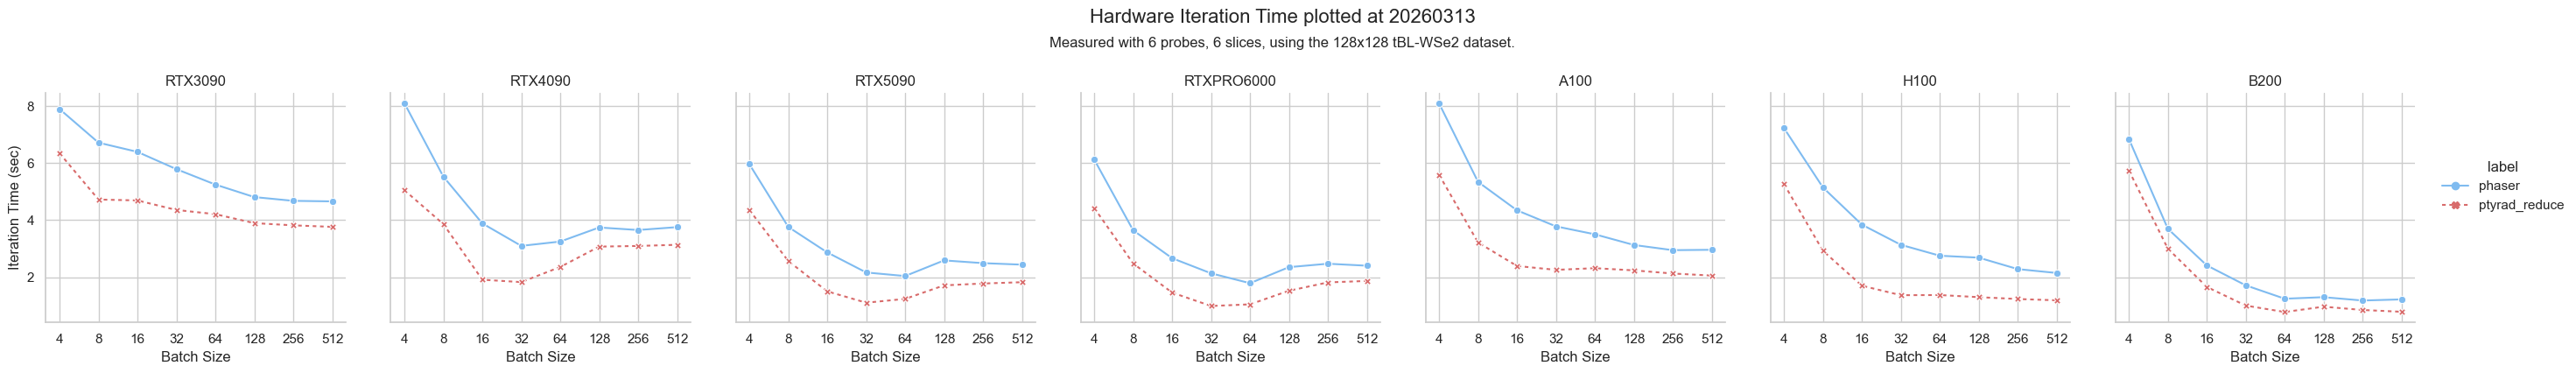

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import datetime

# ==========================================
# 0. DEFINE YOUR PLOT SUBSET
# ==========================================
plot_packages = [
    "phaser", 
    "ptyrad_reduce"
    ]

plot_batches = [4, 8, 16, 32, 64, 128, 256, 512]

# Adjust these strings to exactly match your df_success device column
plot_devices = [
    'RTX3090',
    'RTX4090',
    'RTX5090',
    'RTXPRO6000',
    'A100',
    'H100',
    'B200'
           ]


fixed_pmode = 6
fixed_slice = 6

# ==========================================
# 1. PREP THE DATA
# ==========================================
# Filter down to just this specific sweep
df_plot = df_success[
    df_success['label'].isin(plot_packages) &
    df_success['batch'].isin(plot_batches) &
    df_success['device'].isin(plot_devices) &
    (df_success['pmode'] == fixed_pmode) &
    (df_success['slice'] == fixed_slice)
].copy()

# Enforce ordering so the panels and legend appear in a logical sequence
df_plot['device'] = pd.Categorical(df_plot['device'], categories=plot_devices, ordered=True)
df_plot['label'] = pd.Categorical(df_plot['label'], categories=plot_packages, ordered=True)

# ==========================================
# 2. DYNAMIC STYLING SETUP
# ==========================================
# Keep the styling consistent with your pastel theme
package_colors = {
    "phaser": "#7fbbf0",       # Blue
    "ptyrad_reduce": "#D86B6B" # Red
}

sns.set_theme(style="whitegrid")

# ==========================================
# 3. BUILD THE FACETED GRID
# ==========================================
g = sns.relplot(
    data=df_plot,
    x="batch",
    y="clean_iter_time",   # Back to Iteration Time! (Lower is better)
    hue="label",           # Color by Software
    style="label",         # Solid vs Dashed for Software
    col="device",          # Create a separate panel for EVERY GPU
    kind="line",
    markers=True,
    dashes=["", (2, 2)],   # Solid line for Phaser, dashed for PtyRAD (or vice versa)
    height=4,
    aspect=1.0,            # Square panels look best when side-by-side
    palette=package_colors,
    hue_order=plot_packages,
    col_order=plot_devices,
    facet_kws={'sharey': True, 'sharex': True} # Lock Y-axis to show absolute hardware speedups
)

# ==========================================
# 4. SCALING, LABELS & EXPORT
# ==========================================
batch_ticks = plot_batches

# Set X to log scale
g.set(xscale="log")

formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)

for ax in g.axes.flat:
    # --- X-AXIS ---
    ax.set_xticks(batch_ticks)
    ax.set_xticklabels([str(b) for b in batch_ticks])
    ax.set_xlabel("Batch Size")

# Clean up titles
g.set_axis_labels(x_var="Batch Size", y_var="Iteration Time (sec)")
g.set_titles(template="{col_name}") # Titles will just show the GPU name (e.g., "H100")

# Master Title & Layout
g.figure.subplots_adjust(top=0.82, wspace=0.15)

g.figure.suptitle(f"Hardware Iteration Time plotted at {date_str}", fontsize=16, y=1.06)

g.figure.text(0.5, 0.98, f"Measured with {fixed_pmode} probes, {fixed_slice} slices, using the 128x128 tBL-WSe2 dataset.", 
         ha='center', va='top', fontsize=12)

# Export (Optional)
fig_name = f"hardware_iter_time_facet_grid_batches_{date_str}"
plt.savefig(f"{output_dir}/{fig_name}.png", bbox_inches="tight")
plt.show()

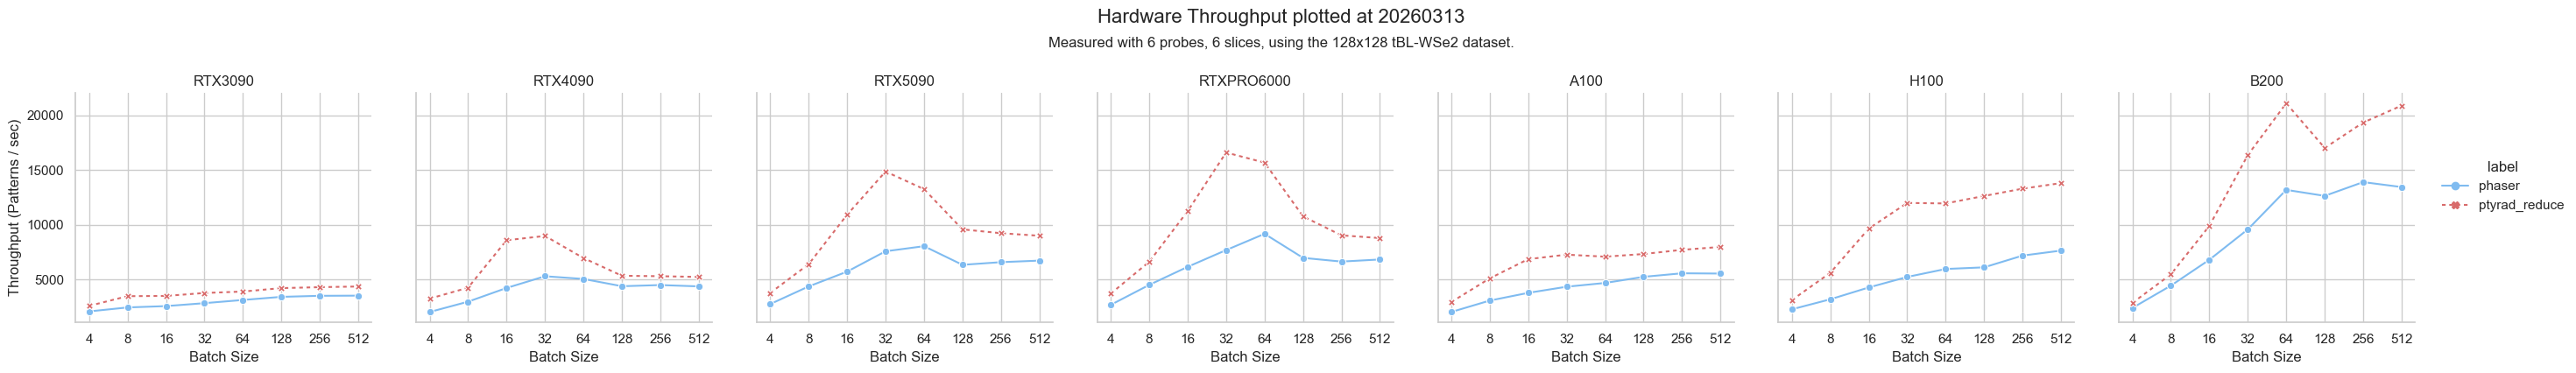

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import datetime
import os

# ==========================================
# 0. DEFINE YOUR PLOT SUBSET
# ==========================================
plot_packages = [
    "phaser", 
    "ptyrad_reduce"
]

plot_batches = [4, 8, 16, 32, 64, 128, 256, 512]

# Adjust these strings to exactly match your df_success device column
plot_devices = [
    'RTX3090',
    'RTX4090',
    'RTX5090',
    'RTXPRO6000',
    'A100',
    'H100',
    'B200'
]

fixed_pmode = 6
fixed_slice = 6

# ==========================================
# 1. PREP THE DATA
# ==========================================
# Filter down to just this specific sweep
df_plot = df_success[
    df_success['label'].isin(plot_packages) &
    df_success['batch'].isin(plot_batches) &
    df_success['device'].isin(plot_devices) &
    (df_success['pmode'] == fixed_pmode) &
    (df_success['slice'] == fixed_slice)
].copy()

# --> CALCULATE Throughput <--
# Nscans / Iteration Time = Patterns per Second
df_plot['throughput'] = df_plot['Nscans'] / df_plot['clean_iter_time']

# Enforce ordering so the panels and legend appear in a logical sequence
df_plot['device'] = pd.Categorical(df_plot['device'], categories=plot_devices, ordered=True)
df_plot['label'] = pd.Categorical(df_plot['label'], categories=plot_packages, ordered=True)

# ==========================================
# 2. DYNAMIC STYLING SETUP
# ==========================================
package_colors = {
    "phaser": "#7fbbf0",       # Blue
    "ptyrad_reduce": "#D86B6B" # Red
}

sns.set_theme(style="whitegrid")

# ==========================================
# 3. BUILD THE FACETED GRID
# ==========================================
g = sns.relplot(
    data=df_plot,
    x="batch",
    y="throughput",             # Now plotting throughput! (Higher is better)
    hue="label",           
    style="label",         
    col="device",          
    kind="line",
    markers=True,
    dashes=["", (2, 2)],   
    height=4,
    aspect=1.0,            
    palette=package_colors,
    hue_order=plot_packages,
    col_order=plot_devices,
    facet_kws={'sharey': True, 'sharex': True} 
)

# ==========================================
# 4. SCALING, LABELS & EXPORT
# ==========================================
batch_ticks = plot_batches

# Restore Y to log scale to capture the massive difference between RTX3090 and B200
g.set(xscale="log")

formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)

for ax in g.axes.flat:
    # --- X-AXIS ---
    ax.set_xticks(batch_ticks)
    ax.set_xticklabels([str(b) for b in batch_ticks])
    ax.set_xlabel("Batch Size")

# Clean up titles
g.set_axis_labels(x_var="Batch Size", y_var="Throughput (Patterns / sec)")
g.set_titles(template="{col_name}")

# Master Title & Layout
g.figure.subplots_adjust(top=0.82, wspace=0.15)

date_str = datetime.datetime.now().strftime("%Y%m%d")
g.figure.suptitle(f"Hardware Throughput plotted at {date_str}", fontsize=16, y=1.06)

g.figure.text(0.5, 0.98, f"Measured with {fixed_pmode} probes, {fixed_slice} slices, using the 128x128 tBL-WSe2 dataset.", 
         ha='center', va='top', fontsize=12)

# Export (Optional)
output_dir = 'figures/'
os.makedirs(output_dir, exist_ok=True)
fig_name = f"hardware_throughput_facet_grid_batches_{date_str}"
plt.savefig(f"{output_dir}/{fig_name}.png", bbox_inches="tight")
plt.show()